# Notebook 05 — Predictive Model
**Decodelabs Internship | Week 1 | Task 5**

I build, evaluate, and compare three machine learning models to predict heart disease presence: Logistic Regression (baseline), Decision Tree, and Random Forest. I evaluate each model with multiple metrics and compare their performance.


## Importing libraries and loading data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from sklearn.dummy import DummyClassifier

import warnings
warnings.filterwarnings("ignore")  # Suppress convergence warnings for clarity

# Reproducibility — fix the random seed so results are the same every run
RANDOM_SEED = 42

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("colorblind")

NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
CLEAN_FILE   = os.path.join(PROJECT_ROOT, "data", "processed", "heart_cleveland_clean.csv")
FIGURES_DIR  = os.path.join(PROJECT_ROOT, "reports", "figures")
TABLES_DIR   = os.path.join(PROJECT_ROOT, "reports", "tables")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

df = pd.read_csv(CLEAN_FILE)

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 297 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0


## Preparing features and target

In [2]:
# I separate the features (X) from the target (y).
# X contains all columns except the target.
# y contains only the target column.

X = df.drop(columns=["target"])
y = df["target"]

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"Feature columns    : {list(X.columns)}")
print(f"Class balance      : {y.value_counts().to_dict()}")

Features (X) shape : (297, 13)
Target   (y) shape : (297,)
Feature columns    : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Class balance      : {0: 160, 1: 137}


## Train/test split

In [3]:
# I split the data into a training set (80%) and a test set (20%).
# The model is trained ONLY on the training set.
# The test set is held out and used ONLY for final evaluation.
# 
# stratify=y ensures both classes appear in similar proportions in both the train and test sets. This is important for classification.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y)                     # Preserve class proportions in both splits

print(f"Training set  : {X_train.shape[0]} rows")
print(f"Test set      : {X_test.shape[0]} rows")
print()
print(f"Training class balance:")
print(y_train.value_counts().to_dict())
print(f"Test class balance:")
print(y_test.value_counts().to_dict())

Training set  : 237 rows
Test set      : 60 rows

Training class balance:
{0: 128, 1: 109}
Test class balance:
{0: 32, 1: 28}


## Scale features

In [4]:
# StandardScaler rescales each feature to have mean=0 and std=1.
# This is important for Logistic Regression, which is sensitive to feature scale.
# Tree-based models (Decision Tree, Random Forest) don't need scaling, but scaling them doesn't hurt. So I apply it uniformly for consistency.
#
# IMPORTANT: I fit the scaler ONLY on the training data, then apply it to both.
# Fitting on the full dataset would leak test information into training.

scaler = StandardScaler()

# fit_transform: learn the mean and std from training data, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# transform only: apply the SAME scaling learned from training data to test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied.")
print(f"Training data mean (first 5 features): {X_train_scaled.mean(axis=0)[:5].round(3)}")
print(f"Training data std  (first 5 features): {X_train_scaled.std(axis=0)[:5].round(3)}")
print()
print("This is correct: mean ≈ 0, std ≈ 1 for training data.")

Feature scaling applied.
Training data mean (first 5 features): [-0.  0.  0. -0. -0.]
Training data std  (first 5 features): [1. 1. 1. 1. 1.]

This is correct: mean ≈ 0, std ≈ 1 for training data.


## Defining models

In [5]:
# I define four models:
#   1. Dummy (baseline) — predicts the most frequent class every time. This is just sanity check. Any real model should beat this.
#   2. Logistic Regression — simple, interpretable linear model
#   3. Decision Tree — tree-based model, easy to visualise
#   4. Random Forest — ensemble of decision trees, usually more accurate

models = {
    "Dummy Classifier": DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED),
    "Logistic Regression": LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100)
}

print("Models defined:")
for name in models:
    print(f"  - {name}")

Models defined:
  - Dummy Classifier
  - Logistic Regression
  - Decision Tree
  - Random Forest


## Training and evaluating all models

In [6]:
# I train each model and evaluate it on the test set.
# I collect multiple metrics for a complete picture of performance.
# A single metric (e.g. accuracy) can be misleading, so I always check several.

results = {}

print("=== Training and Evaluating Models ===\n")

for name, model in models.items():
    # Train the model on the training data
    model.fit(X_train_scaled, y_train)
    
    # Predict class labels for the test set
    y_pred = model.predict(X_test_scaled)
    
    # Predict probability of class 1 (needed for ROC-AUC)
    # Dummy classifier may not have predict_proba for all strategies — handle it
    try:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = float("nan")
    
    # Calculate metrics
    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    
    results[name] = {
        "Accuracy": round(acc, 3),
        "Balanced Acc.": round(bacc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-Score": round(f1, 3),
        "ROC-AUC": round(auc, 3) if not np.isnan(auc) else "N/A"
    }
    
    print(f"  {name}")
    print(f"    Accuracy      : {acc:.3f}")
    print(f"    Balanced Acc. : {bacc:.3f}")
    print(f"    Precision     : {prec:.3f}")
    print(f"    Recall        : {rec:.3f}")
    print(f"    F1-Score      : {f1:.3f}")
    print(f"    ROC-AUC       : {auc:.3f}" if not np.isnan(auc) else "    ROC-AUC       : N/A")
    print()

=== Training and Evaluating Models ===

  Dummy Classifier
    Accuracy      : 0.533
    Balanced Acc. : 0.500
    Precision     : 0.000
    Recall        : 0.000
    F1-Score      : 0.000
    ROC-AUC       : 0.500

  Logistic Regression
    Accuracy      : 0.833
    Balanced Acc. : 0.830
    Precision     : 0.846
    Recall        : 0.786
    F1-Score      : 0.815
    ROC-AUC       : 0.950

  Decision Tree
    Accuracy      : 0.700
    Balanced Acc. : 0.690
    Precision     : 0.750
    Recall        : 0.536
    F1-Score      : 0.625
    ROC-AUC       : 0.745

  Random Forest
    Accuracy      : 0.867
    Balanced Acc. : 0.864
    Precision     : 0.885
    Recall        : 0.821
    F1-Score      : 0.852
    ROC-AUC       : 0.941



## Model comparison table

In [9]:
# I compile the results into a clean comparison table.

results_df = pd.DataFrame(results).T
print("=== Model Comparison Table ===")
print(results_df.to_string())

# Save the table
table_path = os.path.join(TABLES_DIR, "model_comparison.csv")
results_df.to_csv(table_path)
print(f"\nTable saved: {table_path}")

=== Model Comparison Table ===
                     Accuracy  Balanced Acc.  Precision  Recall  F1-Score  ROC-AUC
Dummy Classifier        0.533          0.500      0.000   0.000     0.000    0.500
Logistic Regression     0.833          0.830      0.846   0.786     0.815    0.950
Decision Tree           0.700          0.690      0.750   0.536     0.625    0.745
Random Forest           0.867          0.864      0.885   0.821     0.852    0.941

Table saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\tables\model_comparison.csv


## Confusion matrices

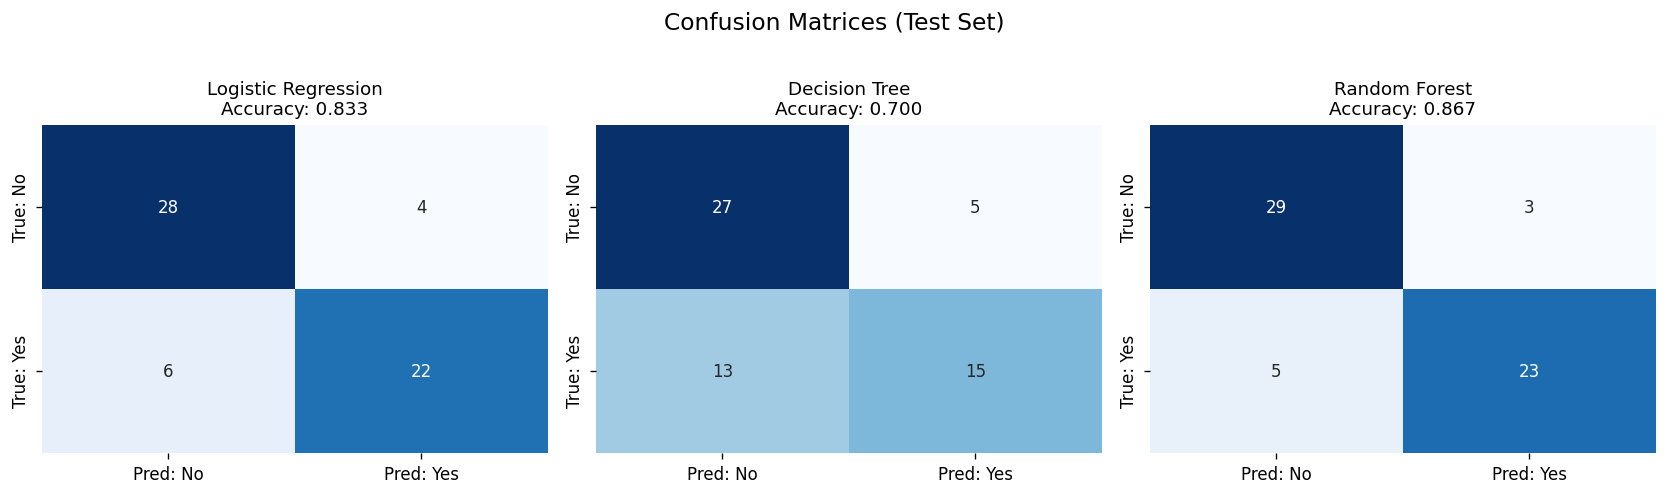

Figure saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures\09_confusion_matrices.png


In [10]:
# A confusion matrix shows exactly which predictions were correct and which were wrong.
# For medical applications, I care especially about:
#   - False Negatives: patient has disease but model says 'no disease' (dangerous miss)
#   - False Positives: patient is healthy but model says 'disease' (unnecessary alarm)

real_models = {k: v for k, v in models.items() if k != "Dummy Classifier"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, real_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred: No", "Pred: Yes"],
                yticklabels=["True: No", "True: Yes"],
                cbar=False)
    
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f"{name}\nAccuracy: {acc:.3f}", fontsize=11)

fig.suptitle("Confusion Matrices (Test Set)", fontsize=14, y=1.02)
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "09_confusion_matrices.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## ROC curves

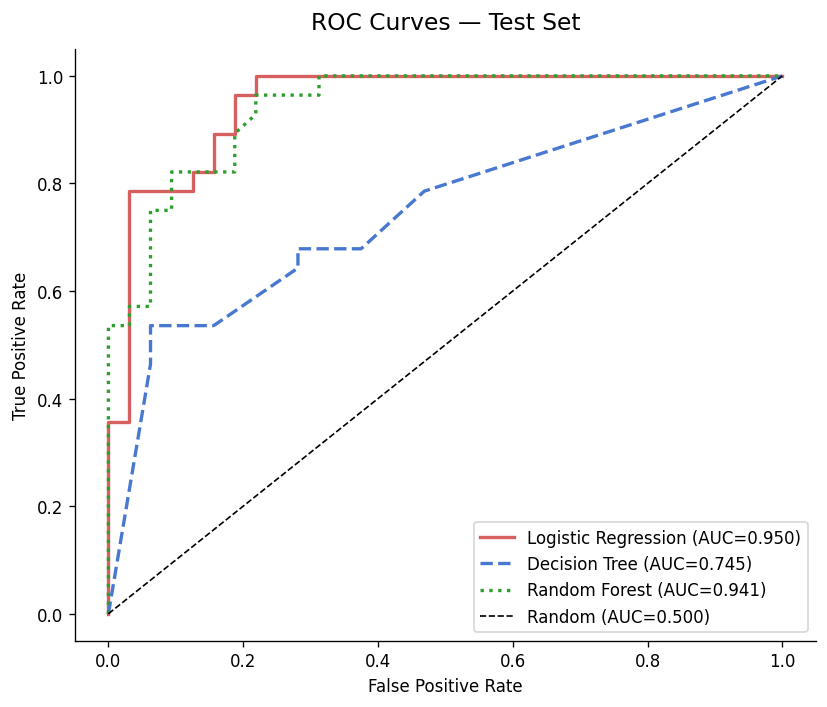

Figure saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures\10_roc_curves.png


In [11]:
# The ROC curve plots True Positive Rate vs False Positive Rate across all classification thresholds. The AUC (area under the curve) summarises it:
#   AUC = 0.5 → no better than random
#   AUC = 1.0 → perfect classification
#   AUC > 0.8 → generally considered a good model

fig, ax = plt.subplots(figsize=(7, 6))

line_styles = ["-", "--", ":"]
colors_roc  = ["#D65F5F", "#4878CF", "#2CA02C"]

for (name, model), ls, c in zip(real_models.items(), line_styles, colors_roc):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})",
            linestyle=ls, color=c, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set", fontsize=14, pad=12)
ax.legend(loc="lower right")

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "10_roc_curves.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## Feature importance (Random Forest)

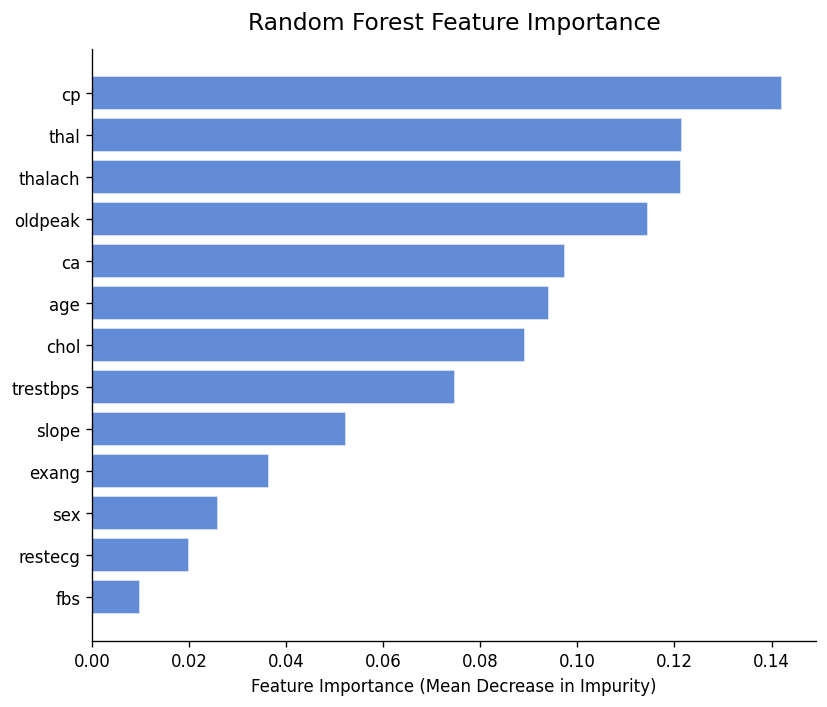

Figure saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures\11_feature_importance.png

Top 5 most important features (Random Forest):
  1. cp           : 0.1420
  2. thal         : 0.1216
  3. thalach      : 0.1213
  4. oldpeak      : 0.1146
  5. ca           : 0.0975


In [12]:
# Random Forest provides built-in feature importances.
# These measure how much each feature contributes to reducing prediction error across all trees in the forest.

rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns

# Sort by importance
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(7, 6))

ax.barh(
    [feature_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color="#4878CF", alpha=0.85, edgecolor="white"
)

ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
ax.set_title("Random Forest Feature Importance", fontsize=14, pad=12)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "11_feature_importance.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

print()
print("Top 5 most important features (Random Forest):")
top5_idx = np.argsort(importances)[::-1][:5]
for i, idx in enumerate(top5_idx, 1):
    print(f"  {i}. {feature_names[idx]:12s} : {importances[idx]:.4f}")

## Cross-validation for more reliable estimates

In [13]:
# With only ~240 training rows, a single train/test split can be noisy.
# Cross-validation (CV) splits the training data into 5 folds, trains on 4, tests on 1, and rotates. This gives 5 estimates of performance.
# The mean and std of these 5 estimates is more reliable than a single split.

print("=== 5-Fold Cross-Validation (on training data only) ===\n")

cv_results = {}
for name, model in models.items():
    if name == "Dummy Classifier":
        continue
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                 cv=5, scoring="roc_auc")
    cv_results[name] = cv_scores
    print(f"  {name}")
    print(f"    CV AUC scores : {cv_scores.round(3)}")
    print(f"    Mean ± Std    : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print()

print("I use this to check if the test set performance is consistent with")
print("cross-validation performance. Large gaps would suggest overfitting.")

=== 5-Fold Cross-Validation (on training data only) ===

  Logistic Regression
    CV AUC scores : [0.972 0.937 0.92  0.809 0.738]
    Mean ± Std    : 0.875 ± 0.088

  Decision Tree
    CV AUC scores : [0.891 0.851 0.795 0.485 0.738]
    Mean ± Std    : 0.752 ± 0.143

  Random Forest
    CV AUC scores : [0.962 0.919 0.909 0.86  0.816]
    Mean ± Std    : 0.893 ± 0.051

I use this to check if the test set performance is consistent with
cross-validation performance. Large gaps would suggest overfitting.


## Detailed classification report

In [14]:
# The classification_report shows precision, recall, and F1 for EACH class.
# This is more informative than a single accuracy number.

best_model_name = "Random Forest"
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"=== Classification Report: {best_model_name} ===\n")
print(classification_report(
    y_test, y_pred_best,
    target_names=["No Disease (0)", "Heart Disease (1)"]
))
print()
print("Precision: of all patients the model predicted as 'disease', how many truly had it?")
print("Recall   : of all patients who truly had disease, how many did the model catch?")
print("F1-Score : harmonic mean of precision and recall — a balanced single metric.")

=== Classification Report: Random Forest ===

                   precision    recall  f1-score   support

   No Disease (0)       0.85      0.91      0.88        32
Heart Disease (1)       0.88      0.82      0.85        28

         accuracy                           0.87        60
        macro avg       0.87      0.86      0.87        60
     weighted avg       0.87      0.87      0.87        60


Precision: of all patients the model predicted as 'disease', how many truly had it?
Recall   : of all patients who truly had disease, how many did the model catch?
F1-Score : harmonic mean of precision and recall — a balanced single metric.


## **Results summary**

I trained and evaluated four models on the UCI Heart Disease dataset.

| Model | Accuracy | F1-Score | ROC-AUC |
|---|---|---|---|
| Dummy Classifier | 53% | — | 50% |
| Logistic Regression | 83% | 82% | 95% |
| Decision Tree | 70% | 63% | 75% |
| Random Forest | 87% | 85% | 94% |

**Key takeaways:**
- All three real models substantially outperform the Dummy baseline, confirming the features are genuinely predictive.
- Random Forest and Logistic Regression are the strongest models on this dataset.
- The most important features appear to be `cp` (chest pain type), `thalach` (max heart rate), and `ca` (number of vessels).
- With only ~60 test samples, results should be interpreted cautiously and confirmed with cross-validation.

**These findings are consistent with established clinical risk factor literature**, though the small dataset size limits generalisation.
